# Supervised PCA

In [1]:
from models import SupervisedPCA, spca_normalized_loss
from utils import load_buildings_data
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# set parameters
OUTPUT_DIM = 2

In [3]:
# Prepare data
X, y = load_buildings_data()

# Center features
X = X - X.mean(dim=0)
y = y - y.mean(dim=0)
print(X.shape)
print(y.shape)

torch.Size([1000, 19])
torch.Size([1000, 1])


## Model training
We train the model for different lambdas and keep the one with the best normalized loss.

Smaller lambda puts more weight onto the supervised (prediction) error while a larger lambda puts more weight on the unsupervised (reconstruction) error in the loss function

In [12]:
lambda_candidates = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
best_lambda = None
best_loss = float('inf')
best_model = None
res = []

for lam in lambda_candidates:
    # Initialize a fresh model for each lambda
    model = SupervisedPCA(input_dim=X.shape[1], output_dim=OUTPUT_DIM)
    
    # Train L for this lambda
    print(f"performing SPCA on lambda {lam}")
    model.train(X, y, lam=lam, steps=200)

    # Compute normalized loss
    pred_loss, recon_loss = spca_normalized_loss(X, y, model.L)

    # Save results
    res.append({"lam": lam, "pred_loss": pred_loss.item(), "recon_loss": recon_loss.item(), "history": model.loss_history})

performing SPCA on lambda 0.0001
Step 0: loss = 87858.2104
Step 10: loss = 78989.3588
Step 20: loss = 78838.8761
Step 30: loss = 78755.0917
Step 40: loss = 78684.1864
Step 50: loss = 78294.1417
Step 60: loss = 75214.7348
Step 70: loss = 67301.7684
Step 80: loss = 67278.9037
Step 90: loss = 67278.2065
Step 100: loss = 67277.5120
Step 110: loss = 67276.8227
Step 120: loss = 67276.1385
Step 130: loss = 67275.4593
Step 140: loss = 67274.7850
Step 150: loss = 67274.1156
Step 160: loss = 67273.4512
Step 170: loss = 67272.7917
Step 180: loss = 67272.1373
Step 190: loss = 67271.4883
performing SPCA on lambda 0.001
Step 0: loss = 87887.8133
Step 10: loss = 79099.3422
Step 20: loss = 79040.4600
Step 30: loss = 78989.6424
Step 40: loss = 78938.8744
Step 50: loss = 78889.3004
Step 60: loss = 78845.7446
Step 70: loss = 78804.9216
Step 80: loss = 78756.4926
Step 90: loss = 78698.7780
Step 100: loss = 78627.9628
Step 110: loss = 70673.2797
Step 120: loss = 67233.9968
Step 130: loss = 67182.6714
Step 

## Visualize results

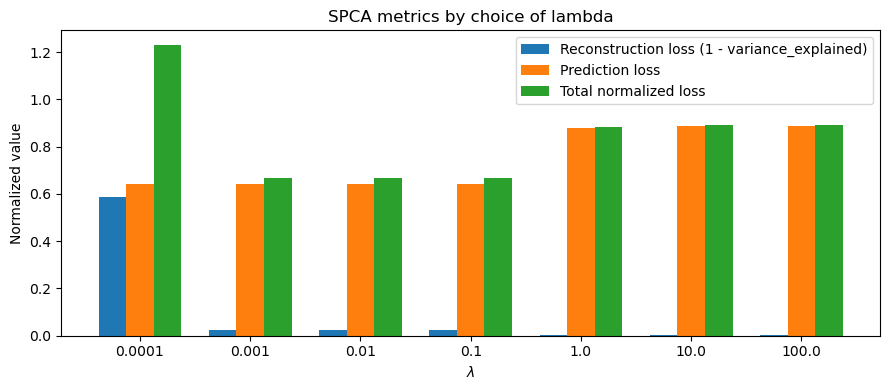

In [13]:
lams = [r["lam"] for r in res]
pred = [float(r["pred_loss"]) for r in res]
recon = [float(r["recon_loss"]) for r in res]
total_norm = [p + r for p, r in zip(pred, recon)]

x = np.arange(len(lams))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width, recon, width, label="Reconstruction loss (1 - variance_explained)")
ax.bar(x, pred, width, label="Prediction loss")
ax.bar(x + width, total_norm, width, label="Total normalized loss")
ax.set_xticks(x)
ax.set_xticklabels([str(lam) for lam in lams])
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Normalized value")
ax.set_title("SPCA metrics by choice of lambda")
ax.legend()
plt.tight_layout()
plt.show()

A lower choice of lambda (lam=0.01) seems to work better, with Prediction loss significantly lower and Reconstruction loss only slightly higher.